## Loading the Data

In [1]:
import zipfile
import os

# List of files to unzip
zip_files = [
    'images_training_rev1.zip', 
    'images_test_rev1.zip', 
    'training_solutions_rev1.zip'
]

base_input_path = '/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge'
base_extract_path = '/kaggle/working/'

for file in zip_files:
    zip_path = os.path.join(base_input_path, file)
    
    # Create a specific folder for images, but keep the CSV in the main working dir
    if 'images' in file:
        folder_name = file.replace('.zip', '')
        extract_path = os.path.join(base_extract_path, folder_name)
    else:
        extract_path = base_extract_path
        
    os.makedirs(extract_path, exist_ok=True)

    print(f"Unzipping {file}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("All files extracted successfully.")

    location_path = os.path.join(base_extract_path, folder_name, folder_name)
    if os.path.exists(location_path):
        files = os.listdir(location_path)
        print(f"✅ Folder found!")
        print(f"Total files in training folder: {len(files)}")
        if len(files) > 0:
            print(f"Sample filename: {files[0]}")
    else:
        print("❌ Folder not found. Check your extraction path.")

Unzipping images_training_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 61578
Sample filename: 467558.jpg
Unzipping images_test_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 79975
Sample filename: 231833.jpg
Unzipping training_solutions_rev1.zip...
All files extracted successfully.
✅ Folder found!
Total files in training folder: 79975
Sample filename: 231833.jpg


## The Training CSV File

In [2]:
import pandas as pd

training_sol = pd.read_csv('/kaggle/working/training_solutions_rev1.csv')

print(training_sol.head(5))

   GalaxyID  Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  \
0    100008  0.383147  0.616853  0.000000  0.000000  0.616853  0.038452   
1    100023  0.327001  0.663777  0.009222  0.031178  0.632599  0.467370   
2    100053  0.765717  0.177352  0.056931  0.000000  0.177352  0.000000   
3    100078  0.693377  0.238564  0.068059  0.000000  0.238564  0.109493   
4    100090  0.933839  0.000000  0.066161  0.000000  0.000000  0.000000   

   Class3.2  Class4.1  Class4.2  ...  Class9.3  Class10.1  Class10.2  \
0  0.578401  0.418398  0.198455  ...  0.000000   0.279952   0.138445   
1  0.165229  0.591328  0.041271  ...  0.018764   0.000000   0.131378   
2  0.177352  0.000000  0.177352  ...  0.000000   0.000000   0.000000   
3  0.129071  0.189098  0.049466  ...  0.000000   0.094549   0.000000   
4  0.000000  0.000000  0.000000  ...  0.000000   0.000000   0.000000   

   Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  Class11.5  Class11.6  
0   0.000000   0.000000   0.092886 

Must translate the decision tree votes/responses into labels.

-> use Willett et al. (2013) -> wrote some notes on the math.

-> Can either use "Hierarchical Thresholding" (math discussed on Gemini, refer to notes) or The "Pseudo-Distribution" Approach (K-L Divergence) -> not as good for grad-cam, want hard boundaries

In [3]:
#Hierarchical Thresholding

def thresh_labels(row, thresh):
    #the standards for the thresholds are 0.8 (from Willett et al. (2013), 0.5, and 0.7 (for the further tasks))
    # Scaled in this definition since lower quality images can be insightful testing data
    # Rule 1: High Consensus Smooth = Elliptical
    if row['Class1.1'] >= thresh:
        return 'Elliptical'
    
    # Rule 2: High Consensus Features + Arms = Spiral
    # (Note: We ignore the small % of 'Smooth' votes here)
    if row['Class1.2'] >= thresh and row['Class4.1'] >= ((5/8)*thresh):
        return 'Spiral'
    
    # Rule 3: High Consensus Artifact or 'Odd' = Irregular
    if row['Class1.3'] >= thresh or row['Class6.1'] >= ((7/8)*thresh):
        return 'Irregular'
    
    # Rule 4: If no consensus, throw it out! (Prevents noisy training)
    return 'Uncertain'

In [4]:
target_thresh = 0.8

# 3. Apply the function to create a new column
# 'args' passes the thresh value to your function
training_sol['label'] = training_sol.apply(thresh_labels, axis=1, thresh=target_thresh)

# 4. Filter out the 'Uncertain' rows to get your final labeled DF
train_sol_labeled = training_sol[training_sol['label'] != 'Uncertain'].copy()

# 5. Check the results
print(f"Original size: {len(training_sol)}")
print(f"Labeled size: {len(train_sol_labeled)}")
print(train_sol_labeled['label'].value_counts())

Original size: 61578
Labeled size: 20529
label
Spiral        9107
Elliptical    8132
Irregular     3290
Name: count, dtype: int64


-> should consider data augmentation, esp for irregular

## EDA of the Images

### Visualizing Class Prototypes

In [5]:
import matplotlib.pyplot as plt
import cv2
import os

def plot_class_samples(df, label, img_path, n=5):
    # Get top 5 most confident samples for that label
    samples = df[df['label'] == label].sample(n) 
    
    plt.figure(figsize=(15, 5))
    for i, (idx, row) in enumerate(samples.iterrows()):
        img = cv2.imread(os.path.join(img_path, f"{int(row['GalaxyID'])}.jpg"))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{label}\nID: {int(row['GalaxyID'])}")
        plt.axis('off')
    plt.show()

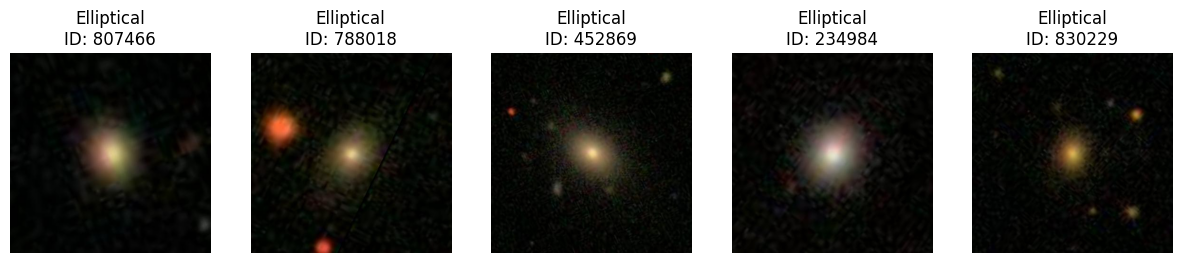

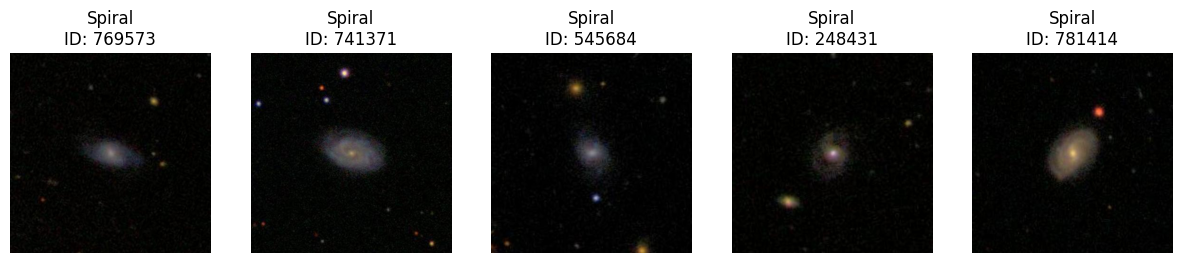

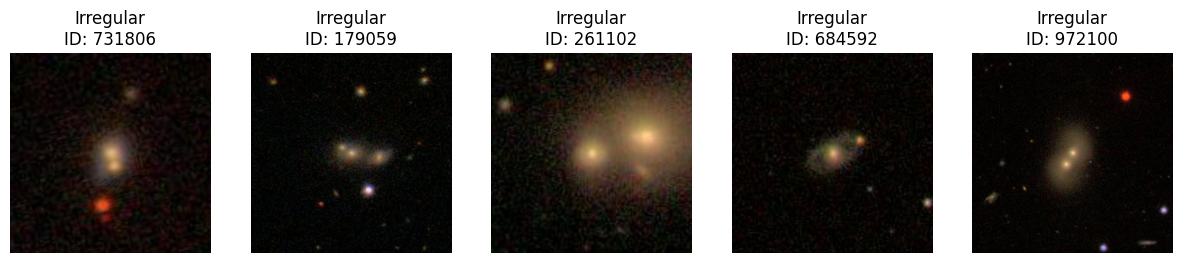

In [6]:
# Run for each class
for cls in ['Elliptical', 'Spiral', 'Irregular']:
    plot_class_samples(train_sol_labeled, cls, '/kaggle/working/images_training_rev1/images_training_rev1')

- see the source of error which is self-ascribing hard labels
- Spiral and Elliptical are okay
- Irregular not so much. Maybe works as a control set? Either forces the model to learn the features of the other two classes, or it will confuse the model.

### Color Space & Intensity Distribution

Since galaxies and their images can vary greatly in their intensity, we need to ensure that the model learns the shapes and not the values of the pixels.

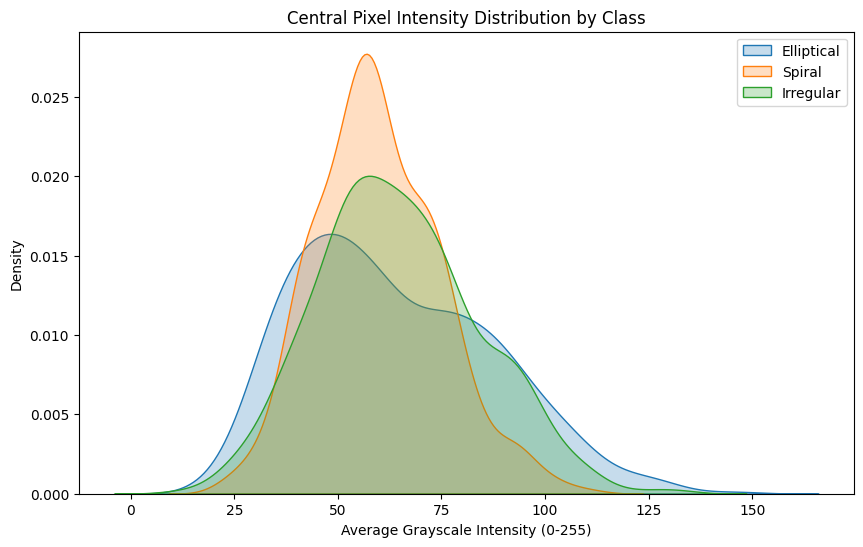

In [7]:
import numpy as np
import seaborn as sns

def plot_intensity_distribution(df, img_path, sample_size=500):
    plt.figure(figsize=(10, 6))
    
    for label in ['Elliptical', 'Spiral', 'Irregular']:
        # Sample images from the class
        subset = df[df['label'] == label].sample(min(sample_size, len(df[df['label']==label])))
        intensities = []
        
        for _, row in subset.iterrows():
            img = cv2.imread(os.path.join(img_path, f"{int(row['GalaxyID'])}.jpg"), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Focus on the center 100x100 pixels where the galaxy lives
                h, w = img.shape
                center = img[h//2-50:h//2+50, w//2-50:w//2+50]
                intensities.append(np.mean(center))
        
        sns.kdeplot(intensities, label=label, fill=True)

    plt.title("Central Pixel Intensity Distribution by Class")
    plt.xlabel("Average Grayscale Intensity (0-255)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Run this using your verified actual_img_path
img_path = '/kaggle/working/images_training_rev1/images_training_rev1'
plot_intensity_distribution(train_sol_labeled, img_path)

There is a very prominent overlap, which means that there is no need to equalize the image intensity.

### Image Aspect Ratio and Resolution

Showing the crop that will be fed into the model to ensure that there is no dead space, adding noise and uncertainty to the model. This is important for testing/validation and especially Grad-CAM which requires consistency. Training needs a random crop to ensure that the model is spatially independent.

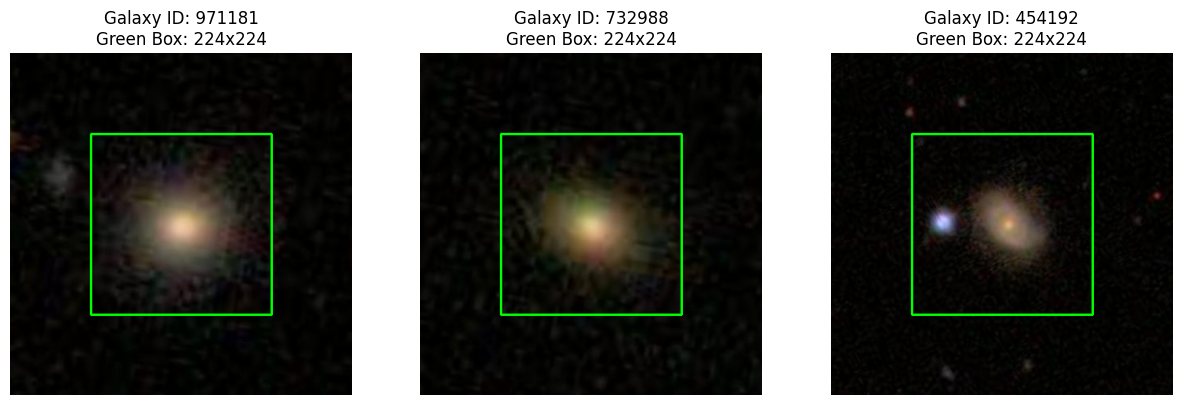

In [8]:
import cv2
import matplotlib.pyplot as plt
import os

def plot_dead_space_check(df, img_path, box_size=224, n=3):
    samples = df.sample(n)
    plt.figure(figsize=(15, 5))
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        img_bgr = cv2.imread(os.path.join(img_path, f"{int(row['GalaxyID'])}.jpg"))
        if img_bgr is None: continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape # Usually 424, 424
        
        # Calculate the top-left and bottom-right of the 224x224 center box
        start_point = (w // 2 - box_size // 2, h // 2 - box_size // 2)
        end_point = (w // 2 + box_size // 2, h // 2 + box_size // 2)
        
        # Draw a Green box (color is RGB here) with thickness 2
        cv2.rectangle(img_rgb, start_point, end_point, (0, 255, 0), 2)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img_rgb)
        plt.title(f"Galaxy ID: {int(row['GalaxyID'])}\nGreen Box: {box_size}x{box_size}")
        plt.axis('off')
    
    plt.show()

# Run the check
plot_dead_space_check(train_sol_labeled, img_path)

We see that 224 x 224 centers on the galaxies well and eliminates any background features.

### Size of the images

In [9]:
import cv2
import os

# Load a single sample image
sample_id = train_sol_labeled.iloc[0]['GalaxyID']
img = cv2.imread(os.path.join(img_path, f"{int(sample_id)}.jpg"))

# Get the shape
height, width, channels = img.shape

print(f"Dimensions: {width} x {height}")
print(f"Channels: {channels}")

Dimensions: 424 x 424
Channels: 3


## Goals for Preprocessing

- Get a Deterministic Split -> use Stratified Split
- Crop image for model input
- Add randomness for training and ONLY training
- Data Augmentation
- .npy files for faster data loading -> OPTIONAL only if GPU is starving
- normalization of Torch tensors -> Local Mean/Std Calc
- Add weighted sampler before training